# LoRA fine-tuning: стандартный loss HF против CCE

Аналог рис. 4 статьи: кривые loss при обучении с CCE и без неё должны совпадать.

**Порядок запуска.** `cce_patch` подменяет forward модели во всём процессе Python, поэтому прогоны идут в разных ядрах:
1. `LOSS_IMPL = "hf"` → Run All.
2. **Restart kernel**, `LOSS_IMPL = "cce"` → Run All.
3. Раздел «Сравнение прогонов» читает только CSV из `results/`, его можно запускать в любом ядре.

Если не хватает памяти: уменьшить `batch_size` и увеличить `grad_accum` (эффективный батч тот же) или включить `gradient_checkpointing`.

In [1]:
%load_ext autoreload
%autoreload 2

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch

DEVICE = "cuda"
RESULTS = Path("results")
RESULTS.mkdir(exist_ok=True)

## 1. Настройки

In [2]:
from finetune import FinetuneConfig

LOSS_IMPL = "cce"   # "hf" или "cce"; после смены — перезапустить ядро
MODEL_NAME = "/home/jovyan/shared-longhorn/models/gemma-2-2b-it"
DATA_CSV = "data/alpaca.csv"
MAX_LENGTH = 512
SEED = 0

cfg = FinetuneConfig(
    model_name=MODEL_NAME,
    loss_impl=LOSS_IMPL,
    cce_impl="cce",
    lora_r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    optimizer="adamw",
    lr=2e-4,
    warmup_steps=20,
    num_steps=300,
    batch_size=4,
    grad_accum=2,            # эффективный батч = 8 примеров
    max_grad_norm=1.0,
    gradient_checkpointing=False,
    seed=SEED,
    log_every=1,
    log_path=str(RESULTS / f"finetune_{LOSS_IMPL}.csv"),
)
cfg

There was a problem when trying to write in your cache folder (/hf/hub). You should set the environment variable TRANSFORMERS_CACHE to a writable directory.
2026-10-07 11:30:47.545669: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-10-07 11:30:47.577083: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-10-07 11:30:47.577124: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-10-07 11:30:47.577148: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factor

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

2026-10-07 11:30:48.244804: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

FinetuneConfig(model_name='/home/jovyan/shared-longhorn/models/gemma-2-2b-it', loss_impl='cce', cce_impl='cce', lora_r=16, lora_alpha=32, lora_dropout=0.05, lora_target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj'], optimizer='adamw', lr=0.0002, weight_decay=0.0, warmup_steps=20, num_steps=300, batch_size=4, grad_accum=2, max_grad_norm=1.0, gradient_checkpointing=False, seed=0, log_every=1, log_path='results/finetune_cce.csv')

## 2. Модель и данные

In [3]:
from finetune import count_trainable_parameters, load_model_for_finetune

model, tokenizer = load_model_for_finetune(cfg, device=DEVICE)
trainable, total = count_trainable_parameters(model)
print(f"Обучаемых параметров: {trainable / 1e6:.1f}M из {total / 1e6:.0f}M ({100 * trainable / total:.2f}%)")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Обучаемых параметров: 20.8M из 2635M (0.79%)


In [4]:
from preprocessing import count_loss_tokens, load_examples, make_train_dataloader, tokenize_examples

examples = load_examples(DATA_CSV)
tokenized = tokenize_examples(tokenizer, examples, max_length=MAX_LENGTH, mask_prompt=True)
dataloader = make_train_dataloader(tokenized, batch_size=cfg.batch_size, pad_token_id=tokenizer.pad_token_id, seed=SEED)

needed = cfg.num_steps * cfg.grad_accum * cfg.batch_size
print(f"Примеров: {len(tokenized)}, токенов с loss: {count_loss_tokens(tokenized)}")
print(f"За обучение будет показано {needed} примеров ≈ {needed / len(tokenized):.2f} эпохи")

Примеров: 500, токенов с loss: 25656
За обучение будет показано 2400 примеров ≈ 4.80 эпохи


In [5]:
tokenizer.decode(tokenized[0].input_ids)

'<bos>Below is an instruction that describes a task. Write a response that appropriately completes the request.\n\n### Instruction:\nGive three tips for staying healthy.\n\n### Response:\n1.Eat a balanced diet and make sure to include plenty of fruits and vegetables. \n2. Exercise regularly to keep your body active and strong. \n3. Get enough sleep and maintain a consistent sleep schedule.<eos>'

In [6]:
ex = tokenized[0]
print(tokenizer.decode([t for t in ex.labels if t != -100]))
print(sum(l != -100 for l in ex.labels), "из", len(ex.labels), "токенов участвуют в loss")

1.Eat a balanced diet and make sure to include plenty of fruits and vegetables. 
2. Exercise regularly to keep your body active and strong. 
3. Get enough sleep and maintain a consistent sleep schedule.<eos>
46 из 82 токенов участвуют в loss


## 3. Проверка патча

До обучения LoRA-адаптеры нулевые, модель совпадает с исходной. Loss на одном и том же фиксированном батче
в прогоне `hf` и в прогоне `cce` должен совпасть (сравнение — в последнем разделе).

In [7]:
from finetune import evaluate_loss

fixed_batch = next(iter(make_train_dataloader(tokenized, batch_size=cfg.batch_size,
                                              pad_token_id=tokenizer.pad_token_id, shuffle=False)))
init_loss = evaluate_loss(model, fixed_batch, device=DEVICE)
(RESULTS / f"finetune_{LOSS_IMPL}_init_loss.json").write_text(json.dumps({"init_loss": init_loss}))
print(f"{LOSS_IMPL}: loss до обучения = {init_loss:.6f}")

cce: loss до обучения = 1.860582


## 4. Обучение

In [8]:
from finetune import train

log = train(model, dataloader, cfg, device=DEVICE)
log.tail()

,step,loss,lr,peak_mem_mb,step_time_s,tokens_per_s
295,296,0.060272,2.857143e-06,10719.871582,0.258869,1576.085104
296,297,0.137053,2.142857e-06,9837.574219,0.255192,1892.693552
297,298,0.137252,1.428571e-06,10173.180664,0.247382,1815.003498
298,299,0.248593,7.142857e-07,15481.518555,0.341580,1744.833893
299,300,0.117662,0.000000e+00,11723.633789,0.294716,1713.516753


## 5. Максимальный батч (необязательно, аналог рис. 1)

Удвоением и двоичным поиском ищем наибольший батч фиксированной длины, который помещается в память.
Запускать после обучения: при поиске будут намеренные OOM.

In [9]:
from finetune import find_max_batch_size, make_random_batch_factory

SEQ_LEN = 512
make_batch = make_random_batch_factory(vocab_size=model.config.vocab_size, seq_len=SEQ_LEN)
max_bs = find_max_batch_size(model, make_batch, start=1, limit=256, device=DEVICE)
(RESULTS / f"finetune_{LOSS_IMPL}_max_batch.json").write_text(json.dumps({"seq_len": SEQ_LEN, "max_batch": max_bs}))
print(f"{LOSS_IMPL}: максимальный батч при длине {SEQ_LEN} = {max_bs} ({max_bs * SEQ_LEN} токенов)")

cce: максимальный батч при длине 512 = 10 (5120 токенов)


## 6. Сравнение прогонов (читает только файлы из results/)

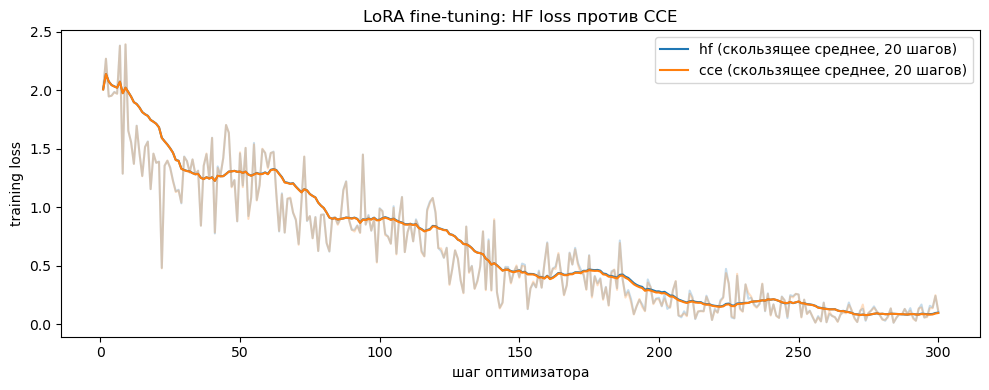

In [10]:
def read_json(path: Path) -> dict:
    return json.loads(path.read_text()) if path.exists() else {}


runs = {impl: pd.read_csv(RESULTS / f"finetune_{impl}.csv")
        for impl in ("hf", "cce") if (RESULTS / f"finetune_{impl}.csv").exists()}

fig, ax = plt.subplots(figsize=(10, 4))
for impl, df in runs.items():
    line, = ax.plot(df["step"], df["loss"], alpha=0.25)
    ax.plot(df["step"], df["loss"].rolling(20, min_periods=1).mean(), color=line.get_color(),
            label=f"{impl} (скользящее среднее, 20 шагов)")
ax.set_xlabel("шаг оптимизатора")
ax.set_ylabel("training loss")
ax.set_title("LoRA fine-tuning: HF loss против CCE")
ax.legend()
fig.tight_layout()
fig.savefig(RESULTS / "finetune_loss_curves.png", dpi=150)

In [11]:
summary = pd.DataFrame({
    impl: {
        "init_loss": read_json(RESULTS / f"finetune_{impl}_init_loss.json").get("init_loss"),
        "loss_last50_mean": df["loss"].tail(50).mean(),
        "peak_mem_mb_max": df["peak_mem_mb"].max(),
        "tokens_per_s_median": df["tokens_per_s"].iloc[5:].median(),   # первые шаги — прогрев
        "step_time_s_median": df["step_time_s"].iloc[5:].median(),
        "max_batch": read_json(RESULTS / f"finetune_{impl}_max_batch.json").get("max_batch"),
    }
    for impl, df in runs.items()
}).T
summary.to_csv(RESULTS / "finetune_summary.csv")

if {"hf", "cce"} <= runs.keys():
    diff = (runs["cce"]["loss"] - runs["hf"]["loss"]).abs()
    print(f"|loss_cce − loss_hf| по шагам: среднее {diff.mean():.4f}, максимум {diff.max():.4f}")
summary

|loss_cce − loss_hf| по шагам: среднее 0.0069, максимум 0.0509


,init_loss,loss_last50_mean,peak_mem_mb_max,tokens_per_s_median,step_time_s_median,max_batch
hf,1.861646,0.092311,21975.446289,1514.787964,0.249503,6.0
cce,1.860582,0.090552,15664.927734,1640.359792,0.234288,10.0
